# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсоток даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)

pd.set_option('display.max_columns', None)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Data Analyst/ML/credit_risk_dataset.csv')

rows, cols = df.shape
print(f'Датасет: {rows:,} записів, {cols} колонок')
df.head()

Датасет: 32,581 записів, 12 колонок


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
# Перевірка пропусків
nulls = df.isnull().sum()
nulls[nulls > 0]

,0
person_emp_length,895
loan_int_rate,3116


In [6]:
# Розподіл цільової змінної
target_dist = df['loan_status'].value_counts(normalize=True) * 100

for status, pct in target_dist.items():
    label = 'сплачено' if status == 0 else 'дефолт'
    print(f'{status} ({label}): {pct:.1f}%')

0 (сплачено): 78.2%
1 (дефолт): 21.8%


**Висновок**

Датасет складається з 32 581 записів та 12 ознак.           
Виявлено пропуски у двох колонках: `person_emp_length` (895 записів) та `loan_int_rate` (3 116 записів).

Цільова змінна `loan_status` розподілена нерівномірно: ~78% — клієнти без дефолту, ~22% — з дефолтом.       
Це задача незбалансованої класифікації, що потрібно враховувати при оцінці якості моделі — accuracy тут може бути оманливою метрикою.


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [7]:
# 1. Відсоток пропусків та їх заповнення

missing_pct = (nulls[nulls > 0] / len(df) * 100).round(2)
print('Пропущені значення (%):')
print(missing_pct)

Пропущені значення (%):
person_emp_length    2.75
loan_int_rate        9.56
dtype: float64


In [8]:
# Обидві колонки числові — заповнення медіаною
cols_with_nulls = ['person_emp_length', 'loan_int_rate']

df[cols_with_nulls] = df[cols_with_nulls].fillna(df[cols_with_nulls].median())

# Перевірка
print(f'\nПропусків залишилось: {df[cols_with_nulls].isnull().sum().sum()}')


Пропусків залишилось: 0


In [9]:
# 2. Розподіл числових змінних

df.select_dtypes('number').describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.77,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.09,6322.09,3.08,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,8.49,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.11,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


Зі статистики видно підозрілі значення: `person_age` max = 144 (нереалістичний вік), `person_income` max = 6 000 000 (при медіані 55 000), `person_emp_length` max = 123 (стаж 123 роки). Це свідчить про наявність викидів або помилок у даних.

In [10]:
# 3. Обробка викидів у person_income методом IQR

q1, q3 = df['person_income'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr

# Нижня межа = q1 - 1.5*iqr = -22550 — не застосовується, дохід не може бути від'ємним

mask_outliers = df['person_income'] > upper_limit

print(f'Q1 = {q1:,.0f} | Q3 = {q3:,.0f} | IQR = {iqr:,.0f}')
print(f'Верхня межа: {upper_limit:,.0f}')
print(f'Викидів: {mask_outliers.sum()} ({mask_outliers.mean() * 100:.2f}% датасету)')

Q1 = 38,500 | Q3 = 79,200 | IQR = 40,700
Верхня межа: 140,250
Викидів: 1484 (4.55% датасету)


In [11]:
# Обмежуємо викиди верхньою межею (clipping), щоб не втрачати рядки
df['person_income'] = df['person_income'].clip(upper=upper_limit)

print(f'Max person_income після clipping: {df["person_income"].max():,.0f}')

Max person_income після clipping: 140,250


За методом IQR у `person_income` знайдено ~4.6% викидів. Замість видалення рядків застосовано clipping — екстремальні значення обмежені верхньою межею. Це дозволяє зберегти весь обсяг даних, але прибрати вплив аномально високих доходів на модель.

In [12]:
# 4. Аналіз категоріальних змінних відносно цільової

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    stats = (
        df.groupby(col)['loan_status']
        .agg(['count', 'mean'])
        .rename(columns={'count': 'к-сть', 'mean': 'default_rate'})
        .sort_values('default_rate', ascending=False)
        .round(3)
    )
    print(f'\n--- {col} ---')
    display(stats)


--- person_home_ownership ---


,к-сть,default_rate
person_home_ownership,,
RENT,16446,0.316
OTHER,107,0.308
MORTGAGE,13444,0.126
OWN,2584,0.075



--- loan_intent ---


,к-сть,default_rate
loan_intent,,
DEBTCONSOLIDATION,5212,0.286
MEDICAL,6071,0.267
HOMEIMPROVEMENT,3605,0.261
PERSONAL,5521,0.199
EDUCATION,6453,0.172
VENTURE,5719,0.148



--- loan_grade ---


,к-сть,default_rate
loan_grade,,
G,64,0.984
F,241,0.705
E,964,0.644
D,3626,0.590
C,6458,0.207
B,10451,0.163
A,10777,0.100



--- cb_person_default_on_file ---


,к-сть,default_rate
cb_person_default_on_file,,
Y,5745,0.378
N,26836,0.184


Категоріальні змінні чітко розрізняють групи ризику. Кредитний рейтинг `loan_grade` — найсильніший сигнал: для класу G дефолт сягає 98.4%, для A — лише 10%. Також помітний зв'язок з типом житла (RENT — 31.6% дефолтів vs OWN — 7.5%) та історією дефолтів (Y — 37.8% vs N — 18.4%).

In [13]:
# 5. Візуалізація зв'язку ознак з цільовою змінною

# Текстова версія цільової змінної для графіків
df['status_label'] = df['loan_status'].map({0: 'Без дефолту', 1: 'Дефолт'})

In [14]:
# Процентна ставка vs дефолт
fig = px.box(
    df, x='status_label', y='loan_int_rate',
    color='status_label',
    title='Процентна ставка залежно від статусу кредиту',
    labels={'loan_int_rate': 'Процентна ставка', 'status_label': 'Статус'}
)
fig.update_layout(height=450, showlegend=False)
fig.show()

In [15]:
# Частка кредиту від доходу vs дефолт
fig = px.box(
    df, x='status_label', y='loan_percent_income',
    color='status_label',
    title='Відношення кредиту до доходу залежно від статусу кредиту',
    labels={'loan_percent_income': 'Кредит / дохід', 'status_label': 'Статус'}
)
fig.update_layout(height=450, showlegend=False)
fig.show()

In [16]:
# Дефолт по кредитному рейтингу
grade_default = (
    df.groupby('loan_grade')['loan_status'].mean() * 100
).reset_index()
grade_default.columns = ['Рейтинг', 'Дефолт %']

fig = px.bar(
    grade_default, x='Рейтинг', y='Дефолт %',
    title='Частка дефолтів за кредитним рейтингом',
    color='Дефолт %',
    color_continuous_scale='Reds'
)
fig.update_layout(height=450)
fig.show()

In [17]:
# Дефолт по типу житла
home_default = (
    df.groupby('person_home_ownership')['loan_status'].mean() * 100
).reset_index()
home_default.columns = ['Тип житла', 'Дефолт %']

fig = px.bar(
    home_default.sort_values('Дефолт %', ascending=False),
    x='Тип житла', y='Дефолт %',
    title='Частка дефолтів за типом житла',
    color='Дефолт %',
    color_continuous_scale='Reds'
)
fig.update_layout(height=450)
fig.show()

**Висновок по EDA**

Пропуски у двох числових колонках були заповнені медіаною. Викиди в `person_income` оброблено clipping-ом за верхньою межею IQR.

Графіки підтверджують зв'язок декількох ознак з дефолтом: у клієнтів з дефолтом вища процентна ставка і більша частка кредиту відносно доходу. Кредитний рейтинг — найсильніший предиктор: рейтинги D–G мають частку дефолтів >50%. Ці ознаки будуть корисними для побудови моделі.


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.


In [18]:
# 1. Матриця кореляцій

num_cols = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length', 'loan_status'
]

corr = df[num_cols].corr()

fig = px.imshow(
    corr,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляційна матриця числових змінних',
    labels=dict(color='Кореляція')
)
fig.update_layout(height=550)
fig.show()

З матриці кореляцій видно, що найсильніший зв'язок з `loan_status` мають `loan_percent_income` і `loan_int_rate` (позитивна кореляція) та `person_income` (від'ємна). Це логічно: чим більше навантаження кредиту на дохід і чим вища ставка — тим вищий ризик дефолту.

In [19]:
# 2. Кодування категоріальних змінних

# Відбираємо колонки для моделі
feature_cols_raw = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length',
    'person_home_ownership', 'loan_intent', 'loan_grade',
    'cb_person_default_on_file',
    'loan_status'
]

df_model = df[feature_cols_raw].copy()

# Категоріальні колонки для OHE
cat_to_encode = [
    'person_home_ownership', 'loan_intent',
    'loan_grade', 'cb_person_default_on_file'
]

df_encoded = pd.get_dummies(
    df_model, columns=cat_to_encode,
    drop_first=True, dtype=int
)

print(f'Розмір після кодування: {df_encoded.shape}')
df_encoded.head()

Розмір після кодування: (32581, 23)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1
1,21,9600,5.0,1000,11.14,0.10,2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0
2,25,9600,1.0,5500,12.87,0.57,3,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
3,23,65500,4.0,35000,15.23,0.53,2,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0
4,24,54400,8.0,35000,14.27,0.55,4,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1


In [20]:
# 3. Фінальний набір ознак

X = df_encoded.drop(columns='loan_status')
y = df_encoded['loan_status']

print(f'Ознак (X): {X.shape[1]}')
print(f'Записів: {X.shape[0]}')
print(f'\nКолонки: {list(X.columns)}')

Ознак (X): 22
Записів: 32581

Колонки: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']


**Висновок**

Кореляційна матриця показала, що `loan_percent_income` та `loan_int_rate` мають найпомітніший зв'язок з дефолтом. Категоріальні змінні закодовано через One-Hot Encoding з `drop_first=True` для уникнення мультиколінеарності. У фінальний набір увійшли всі числові та закодовані категоріальні ознаки, оскільки кожна з них потенційно несе корисну інформацію для прогнозування.


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.


In [21]:
# 1-2. Train/Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape[0]:,} записів')
print(f'Test:  {X_test.shape[0]:,} записів')
print(f'\nДефолт у train: {y_train.mean():.1%}')
print(f'Дефолт у test:  {y_test.mean():.1%}')

Train: 26,064 записів
Test:  6,517 записів

Дефолт у train: 21.8%
Дефолт у test:  21.8%


In [22]:
# 3. Масштабування
# fit тільки на train, transform на обидві вибірки

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [23]:
# 4. Навчання логістичної регресії

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_sc, y_train)

print('Модель логістичної регресії навчена')

Модель логістичної регресії навчена


In [24]:
# 5. Прогнози на train та test

y_train_pred = log_reg.predict(X_train_sc)
y_test_pred = log_reg.predict(X_test_sc)

# Ймовірності (потрібні для ROC-кривої та підбору порогу)
y_train_proba = log_reg.predict_proba(X_train_sc)[:, 1]
y_test_proba = log_reg.predict_proba(X_test_sc)[:, 1]

In [25]:
# Приклад прогнозів для перших 5 клієнтів тесту
pd.DataFrame({
    'Реальний': y_test.values[:5],
    'Прогноз': y_test_pred[:5],
    'P(дефолт)': y_test_proba[:5].round(3)
})

,Реальний,Прогноз,P(дефолт)
0,0,0,0.113
1,0,0,0.089
2,0,0,0.008
3,0,0,0.073
4,0,0,0.006


**Висновок**

Дані розділено на train/test у пропорції 80/20 з `stratify=y` для збереження балансу класів. Масштабування зроблено коректно: `fit` тільки на train, `transform` — на обидві вибірки, щоб уникнути data leakage. Модель логістичної регресії навчено, прогнози класів та ймовірностей отримано для обох вибірок.


---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


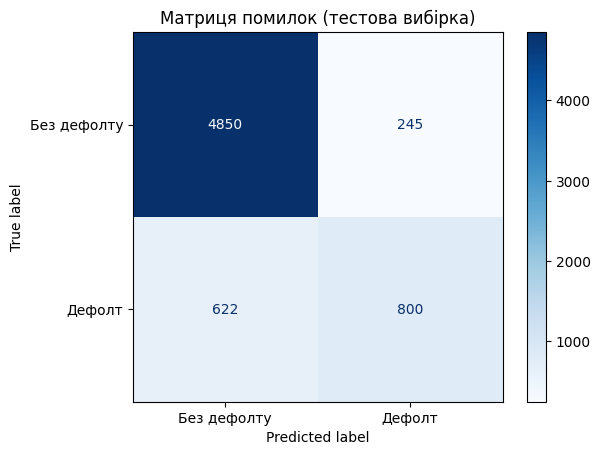

In [27]:
# 1. Confusion Matrix

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Без дефолту', 'Дефолт'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок (тестова вибірка)')
plt.show()

Модель впевнено визначає клієнтів без дефолту. Проте помітна кількість дефолтних клієнтів була помилково класифікована як безпечні (False Negatives). У контексті кредитного ризику це найнебезпечніший тип помилки — банк видає кредит клієнту, який його не поверне.

In [28]:
# 2. Основні метрики

metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1-score': f1_score(y_test, y_test_pred)
}

for name, val in metrics.items():
    print(f'{name}: {val:.3f}')

Accuracy: 0.867
Precision: 0.766
Recall: 0.563
F1-score: 0.649


Accuracy ~0.87 виглядає непогано, але для незбалансованого датасету вона може бути оманливою. Precision ~0.77 означає, що з усіх, кого модель позначила як дефолтних, ~77% справді такими є. Проте Recall ~0.56 показує, що модель знаходить лише трохи більше половини реальних дефолтів — для кредитного ризику це слабкий показник.

In [30]:
# 3. ROC-крива та AUC

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc_val = roc_auc_score(y_test, y_test_proba)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr, y=tpr, mode='lines',
    name=f'Логістична регресія (AUC = {auc_val:.3f})'
))

fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode='lines',
    line=dict(dash='dash', color='red'),
    name='Випадковий класифікатор'
))

fig.update_layout(
    title='ROC-крива',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=500
)
fig.show()

AUC ~0.87 потрапляє в діапазон 0.8–0.9, що свідчить про хорошу розділяючу здатність моделі. Крива значно вище діагоналі — модель працює набагато краще за випадкове вгадування.

In [31]:
# 4. Важливість ознак

importance = pd.DataFrame({
    'Ознака': X.columns,
    'Коефіцієнт': log_reg.coef_[0].round(3)
})

importance['|Коефіцієнт|'] = importance['Коефіцієнт'].abs()
importance = importance.sort_values('|Коефіцієнт|', ascending=False)

# Топ-10
top10 = importance.head(10)

fig = px.bar(
    top10, x='|Коефіцієнт|', y='Ознака',
    orientation='h',
    title='Топ-10 найважливіших ознак',
    labels={'|Коефіцієнт|': 'Абсолютне значення коефіцієнта'}
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=450)
fig.show()

Найвагоміша ознака — `loan_percent_income` (частка кредиту від доходу). Це інтуїтивно зрозуміло: чим більшу частину доходу «з'їдає» кредит, тим вищий ризик. Далі йдуть кредитні рейтинги D та E — їхні позитивні коефіцієнти означають, що належність до цих класів підвищує ймовірність дефолту.

**Загальний висновок по якості моделі**

Логістична регресія дає хороший загальний результат (AUC = 0.87), однак Recall ~0.56 означає, що майже половина дефолтних клієнтів залишається непоміченою. Для бізнесу це критично — кожен пропущений дефолт = прямі фінансові втрати. Тому далі спробуємо оптимізувати поріг класифікації, щоб знайти більше ризикових клієнтів.


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.


In [32]:
# 1. Метрики при різних порогах

threshold_range = np.arange(0.10, 0.85, 0.05)
threshold_metrics = []

for t in threshold_range:
    preds = (y_test_proba >= t).astype(int)
    threshold_metrics.append({
        'Поріг': round(t, 2),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    })

thr_df = pd.DataFrame(threshold_metrics)

# Візуалізація
fig = px.line(
    thr_df.melt(id_vars='Поріг'),
    x='Поріг', y='value', color='variable',
    title='Precision, Recall та F1 при різних порогах',
    labels={'value': 'Значення', 'variable': 'Метрика'}
)
fig.update_layout(height=450)
fig.show()

In [33]:
# Топ-5 порогів за F1
thr_df.sort_values('F1', ascending=False).head(5).round(3)

,Поріг,Precision,Recall,F1
5,0.35,0.663,0.680,0.672
6,0.40,0.697,0.643,0.669
4,0.30,0.622,0.714,0.665
7,0.45,0.736,0.601,0.662
3,0.25,0.577,0.759,0.656


In [34]:
# 2. Обираємо оптимальний поріг

best_threshold = 0.35

y_test_opt = (y_test_proba >= best_threshold).astype(int)

print(f'Обраний поріг: {best_threshold}')
print(f'\nМетрики при порозі {best_threshold}:')
print(f'Accuracy:  {accuracy_score(y_test, y_test_opt):.3f}')
print(f'Precision: {precision_score(y_test, y_test_opt):.3f}')
print(f'Recall:    {recall_score(y_test, y_test_opt):.3f}')
print(f'F1-score:  {f1_score(y_test, y_test_opt):.3f}')

Обраний поріг: 0.35

Метрики при порозі 0.35:
Accuracy:  0.855
Precision: 0.663
Recall:    0.680
F1-score:  0.672


**Висновок**

На графіку чітко видно trade-off між Precision та Recall: зниження порогу збільшує Recall (модель знаходить більше дефолтів), але знижує Precision (більше помилкових спрацювань). Обрано поріг 0.35 як оптимальний для бізнес-задачі — він дає найвищий F1-score і значно підвищує Recall порівняно зі стандартним порогом 0.5. Для банку краще перестрахуватися та додатково перевірити кілька «підозрілих» клієнтів, ніж пропустити реальний дефолт.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Поріг з попереднього завдання
thr = 0.35

# Словник моделей: назва -> (модель, дані для навчання, дані для тесту)
models = {
    'Logistic Regression': (LogisticRegression(random_state=42, max_iter=1000), X_train_sc, X_test_sc),
    'Decision Tree':       (DecisionTreeClassifier(random_state=42, max_depth=5), X_train, X_test),
    'Random Forest':       (RandomForestClassifier(random_state=42, n_estimators=100), X_train, X_test)
}

comparison = []

for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    proba = model.predict_proba(X_te)[:, 1]
    preds = (proba >= thr).astype(int)

    comparison.append({
        'Модель': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'AUC': roc_auc_score(y_test, proba)
    })

comp_df = pd.DataFrame(comparison).round(3)
comp_df

,Модель,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.855,0.663,0.680,0.672,0.870
1,Decision Tree,0.882,0.731,0.726,0.728,0.874
2,Random Forest,0.918,0.845,0.766,0.804,0.930


**Висновок**

Серед трьох моделей Random Forest показав найкращий результат за всіма ключовими метриками: найвищий F1-score, AUC та Accuracy. Decision Tree займає друге місце, а Logistic Regression — третє.

Для задачі кредитного ризику особливо важливий Recall — здатність моделі знаходити дефолтних клієнтів. Random Forest і тут перевершує інші моделі, що робить його найкращим вибором для цієї бізнес-задачі.

Логістична регресія, попри простоту, дає прийнятний базовий результат і має перевагу в інтерпретованості — коефіцієнти моделі дозволяють зрозуміти, які саме фактори впливають на ризик дефолту.